In [ ]:
# one example of D_lst:

# [2,
#   ('Ac_AB4_1_Act01',),
#   ({'qID': 'Ac_AB4_1',
#     'C_T1': 'ob kosilu',
#     'C_T2': 'nan',
#     'C_T3': 'nan',
#     'C_P1': 'kjerkoli',
#     'C_P2': 'nan',
#     'C_P3': 'nan'},),
#   1.875335040596766]

######################3

# vrednosti tega primera: 


# 2: uporabnik ID ali oznaka 
# 
# ('Ac_AB4_1_Act01',): ID aktivnosti 
#
# konteskt (info o času in prostoru): 
# ({'qID': 'Ac_AB4_1',
#     'C_T1': 'ob kosilu',
#     'C_T2': 'nan',
#     'C_T3': 'nan',
#     'C_P1': 'kjerkoli',
#     'C_P2': 'nan',
#     'C_P3': 'nan'},) 
# 
# vrednost(ocena aktinvosti): 1.875335040596766 

In [2]:
import pickle
import numpy as np
from collections import Counter
from pathlib import Path

def analyze_D_lst(D_lst, label="D_lst"):
    scores = [item[3] for item in D_lst if len(item) > 3]
    users = [item[0] for item in D_lst if len(item) > 3]
    seq_lengths = [len(item[1]) for item in D_lst if len(item) > 3]

    all_actions = set()
    for item in D_lst:
        for act in item[1]:
            all_actions.add(act)

    user_freq = Counter(users)

    print(f"\n======= Analysis: {label} =======")
    print(f"Total entries: {len(D_lst)}")
    print(f"Unique users: {len(set(users))}")
    print(f"Unique actions: {len(all_actions)}")

    print(f"Average score: {np.mean(scores):.3f}")
    print(f"Median score: {np.median(scores):.3f}")
    print(f"Standard deviation: {np.std(scores):.3f}")
    print(f"Min score: {np.min(scores):.3f}, Max score: {np.max(scores):.3f}")

    print(f"Average sequence length: {np.mean(seq_lengths):.2f}")
    print(f"Min sequence length: {np.min(seq_lengths)}, Max sequence length: {np.max(seq_lengths)}")
    print(f"Sample user recommendation counts: {dict(list(user_freq.items())[:5])}")

# ====== Load both D_lst files ======

BASE_DIR = Path.cwd().parent  
matD_path = BASE_DIR / 'data'
D_lst_prof = 'D_contx_a3_sparse_mat.pkl'
D_lst_mine = 'D_lst_full.pkl'

# 1. My D_lst
with open(matD_path / D_lst_mine, "rb") as fp:
    D_lst_mine = pickle.load(fp)

# 2. Mentor’s D_lst
with open(matD_path / D_lst_prof, "rb") as fp:
    D_lst_prof = pickle.load(fp)

# ====== Analyze and Compare ======
analyze_D_lst(D_lst_prof, label="Mentor's D_lst")
analyze_D_lst(D_lst_mine, label="My D_lst")



======= Analysis: Mentor's D_lst =======
Total entries: 1850178
Unique users: 679
Unique actions: 34
Average score: 1.289
Median score: 1.232
Standard deviation: 0.817
Min score: 0.310, Max score: 5.000
Average sequence length: 2.89
Min sequence length: 1, Max sequence length: 3
Sample user recommendation counts: {2: 833, 10: 5229, 12: 3723, 13: 6348, 15: 5229}

======= Analysis: My D_lst =======
Total entries: 3053029
Unique users: 679
Unique actions: 34
Average score: 1.541
Median score: 1.273
Standard deviation: 0.840
Min score: 0.300, Max score: 5.000
Average sequence length: 2.92
Min sequence length: 1, Max sequence length: 3
Sample user recommendation counts: {2: 5746, 10: 5229, 12: 5883, 13: 6348, 15: 5229}


In [3]:
print(D_lst_prof[:5])

[[2, ('Ac_AB4_1_Act01',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob kosilu', 'C_T2': 'nan', 'C_T3': 'nan', 'C_P1': 'kjerkoli', 'C_P2': 'nan', 'C_P3': 'nan'},), 1.875335040596766], [2, ('Ac_AB4_1_Act02',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob malici', 'C_T2': 'ob malici', 'C_T3': 'nan', 'C_P1': 'kjerkoli', 'C_P2': 'nan', 'C_P3': 'nan'},), 1.875335040596766], [2, ('Ac_AB4_1_Act03',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob zajtrkui', 'C_T2': 'ob večerji', 'C_T3': 'nan', 'C_P1': 'kjerkoli', 'C_P2': 'nan', 'C_P3': 'nan'},), 1.875335040596766], [2, ('Ac_AB4_1_Act04',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob kosilu', 'C_T2': 'nan', 'C_T3': 'nan', 'C_P1': 'kjerkoli', 'C_P2': 'nan', 'C_P3': 'nan'},), 1.875335040596766], [2, ('Ac_AB4_1_Act05',), ({'qID': 'Ac_AB4_1', 'C_T1': 'podnevi', 'C_T2': 'nan', 'C_T3': 'nan', 'C_P1': 'kjerkoli', 'C_P2': 'nan', 'C_P3': 'nan'},), 1.875335040596766]]


In [4]:
D_lst_prof[1850177]

[2196,
 ('Ac_AB4_5_Act01', 'Ac_AB4_8_Act10', 'Ac_AB4_8_Act11'),
 ({'qID': 'Ac_AB4_5',
   'C_T1': 'zjutraj',
   'C_T2': 'dopoldne',
   'C_T3': 'popoldne',
   'C_P1': 'doma',
   'C_P2': 'nan',
   'C_P3': 'nan'},
  {'qID': 'Ac_AB4_8',
   'C_T1': 'zjutraj',
   'C_T2': 'dopoldne',
   'C_T3': 'zvečer',
   'C_P1': 'doma',
   'C_P2': 'v telovadnici',
   'C_P3': 'v parku'},
  {'qID': 'Ac_AB4_8',
   'C_T1': 'zjutraj',
   'C_T2': 'dopoldne',
   'C_T3': 'zvečer',
   'C_P1': 'doma',
   'C_P2': 'v telovadnici',
   'C_P3': 'v parku'}),
 0.3425561519211241]

In [5]:
D_lst_prof[0]

[2,
 ('Ac_AB4_1_Act01',),
 ({'qID': 'Ac_AB4_1',
   'C_T1': 'ob kosilu',
   'C_T2': 'nan',
   'C_T3': 'nan',
   'C_P1': 'kjerkoli',
   'C_P2': 'nan',
   'C_P3': 'nan'},),
 1.875335040596766]

In [6]:
print(D_lst_mine[:5])

[[2, ('Ac_AB4_1_Act01',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob kosilu', 'C_T2': nan, 'C_T3': nan, 'C_P1': 'kjerkoli', 'C_P2': nan, 'C_P3': nan},), 0.7782542768590307], [2, ('Ac_AB4_1_Act02',), ({'qID': 'Ac_AB4_1', 'C_T1': 'malica dopoldne', 'C_T2': 'malica popoldne', 'C_T3': nan, 'C_P1': 'kjerkoli', 'C_P2': nan, 'C_P3': nan},), 0.7782542768590307], [2, ('Ac_AB4_1_Act03',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob zajtrku', 'C_T2': 'ob večerji', 'C_T3': nan, 'C_P1': 'kjerkoli', 'C_P2': nan, 'C_P3': nan},), 0.7782542768590307], [2, ('Ac_AB4_1_Act04',), ({'qID': 'Ac_AB4_1', 'C_T1': 'ob kosilu', 'C_T2': nan, 'C_T3': nan, 'C_P1': 'kjerkoli', 'C_P2': nan, 'C_P3': nan},), 0.7782542768590307], [2, ('Ac_AB4_1_Act05',), ({'qID': 'Ac_AB4_1', 'C_T1': 'podnevi', 'C_T2': nan, 'C_T3': nan, 'C_P1': 'kjerkoli', 'C_P2': nan, 'C_P3': nan},), 0.7782542768590307]]


In [7]:
D_lst_mine[1850177]

[1258,
 ('Ac_AB4_1_Act05', 'Ac_AB4_3_Act03', 'Ac_AB4_8_Act02'),
 ({'qID': 'Ac_AB4_1',
   'C_T1': 'podnevi',
   'C_T2': nan,
   'C_T3': nan,
   'C_P1': 'kjerkoli',
   'C_P2': nan,
   'C_P3': nan},
  {'qID': 'Ac_AB4_3',
   'C_T1': 'kadarkoli',
   'C_T2': nan,
   'C_T3': nan,
   'C_P1': 'doma',
   'C_P2': 'v telovadnici',
   'C_P3': nan},
  {'qID': 'Ac_AB4_8',
   'C_T1': 'dopoldne',
   'C_T2': 'popoldne',
   'C_T3': nan,
   'C_P1': 'kjerkoli',
   'C_P2': nan,
   'C_P3': nan}),
 1.272930063855819]

In [8]:
D_lst_mine[0]

[2,
 ('Ac_AB4_1_Act01',),
 ({'qID': 'Ac_AB4_1',
   'C_T1': 'ob kosilu',
   'C_T2': nan,
   'C_T3': nan,
   'C_P1': 'kjerkoli',
   'C_P2': nan,
   'C_P3': nan},),
 0.7782542768590307]

In [9]:
import matplotlib.pyplot as plt

def plot_score_histograms(D1, D2, label1="Mentor", label2="Mine"):
    scores1 = [x[3] for x in D1 if len(x) > 3]
    scores2 = [x[3] for x in D2 if len(x) > 3]

    plt.figure(figsize=(10, 5))
    plt.hist(scores1, bins=30, alpha=0.6, label=label1)
    plt.hist(scores2, bins=30, alpha=0.6, label=label2)
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.title("Score Distribution Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
def plot_sequence_lengths(D1, D2, label1="Mentor", label2="Mine"):
    lens1 = [len(x[1]) for x in D1 if len(x) > 3]
    lens2 = [len(x[1]) for x in D2 if len(x) > 3]

    plt.figure(figsize=(8, 4))
    plt.hist(lens1, bins=[1, 2, 3, 4, 5], alpha=0.6, label=label1, rwidth=0.9)
    plt.hist(lens2, bins=[1, 2, 3, 4, 5], alpha=0.6, label=label2, rwidth=0.9)
    plt.xticks([1, 2, 3, 4])
    plt.xlabel("Sequence Length")
    plt.ylabel("Count")
    plt.title("Sequence Length Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
def plot_user_recommendation_counts(D1, D2, label1="Mentor", label2="Mine"):
    from collections import Counter

    counts1 = Counter([x[0] for x in D1 if len(x) > 3])
    counts2 = Counter([x[0] for x in D2 if len(x) > 3])

    plt.figure(figsize=(10, 4))
    plt.hist(list(counts1.values()), bins=20, alpha=0.6, label=label1)
    plt.hist(list(counts2.values()), bins=20, alpha=0.6, label=label2)
    plt.xlabel("Number of Recommendations per User")
    plt.ylabel("User Count")
    plt.title("User Recommendation Count Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


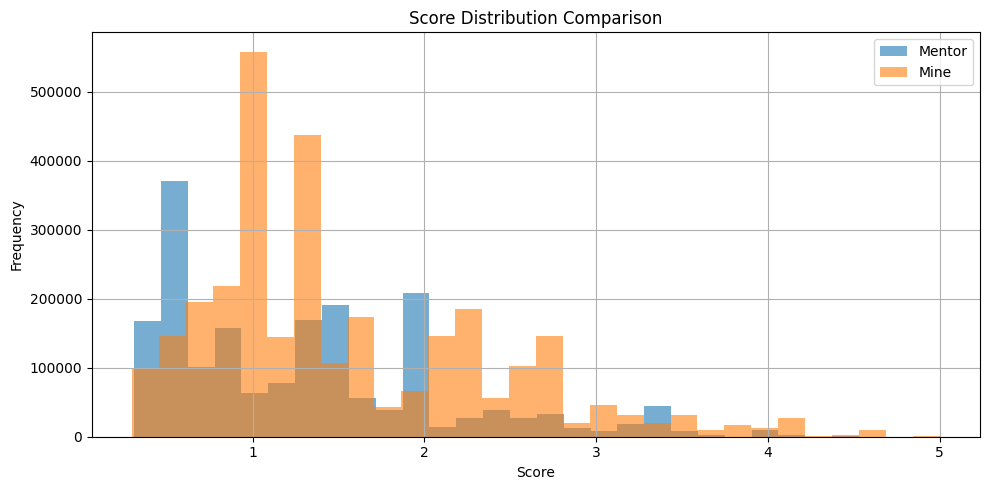

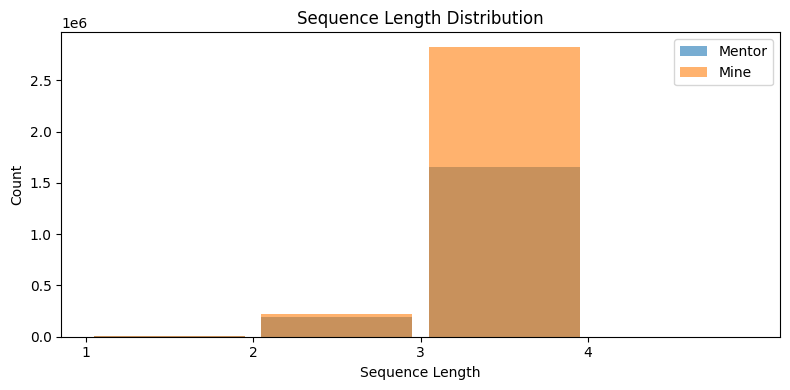

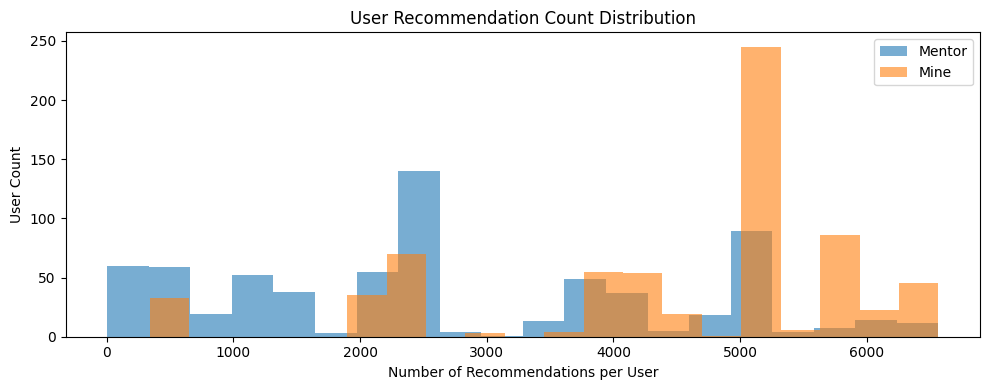

In [12]:
plot_score_histograms(D_lst_prof, D_lst_mine)
plot_sequence_lengths(D_lst_prof, D_lst_mine)
plot_user_recommendation_counts(D_lst_prof, D_lst_mine)